<a href="https://colab.research.google.com/github/Tanay2109/FRTB-Expected-Shortfall-PLA-Validation-Framework/blob/main/FRTB_ES_%26_PLA_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# Import libraries for data handling, statistics, and visualization
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
from scipy.stats import spearmanr, ks_2samp
import matplotlib.pyplot as plt
np.random.seed(42)

In [20]:
# Define a 50-asset portfolio spanning multiple sectors, and map each sector to an FRTB regulatory liquidity horizon (in days)
SECTOR_MAP = {
    'AAPL':'Technology','MSFT':'Technology','GOOGL':'Technology','META':'Technology','NVDA':'Technology',
    'ADBE':'Technology','CRM':'Technology','ORCL':'Technology','CSCO':'Technology','INTC':'Technology',
    'JPM':'Financials','BAC':'Financials','WFC':'Financials','GS':'Financials','MS':'Financials',
    'C':'Financials','AXP':'Financials','BLK':'Financials','SCHW':'Financials','USB':'Financials',
    'PG':'Consumer','KO':'Consumer','PEP':'Consumer','WMT':'Consumer','HD':'Consumer',
    'MCD':'Consumer','NKE':'Consumer','SBUX':'Consumer',
    'JNJ':'Healthcare','PFE':'Healthcare','UNH':'Healthcare','ABBV':'Healthcare',
    'MRK':'Healthcare','TMO':'Healthcare','ABT':'Healthcare','LLY':'Healthcare',
    'XOM':'Energy','CVX':'Energy','COP':'Energy','SLB':'Energy','EOG':'Energy','OXY':'Energy',
    'BA':'Industrials','CAT':'Industrials','GE':'Industrials','HON':'Industrials','UPS':'Industrials',
    'DIS':'Communication','CMCSA':'Communication','T':'Communication'
}
SECTOR_TO_LH = {'Technology':10,'Financials':10,'Consumer':10,'Healthcare':20,'Energy':40,'Industrials':60,'Communication':120}
TICKERS = list(SECTOR_MAP.keys())
LH_BUCKETS = [10,20,40,60,120]
asset_lh = pd.Series({t: SECTOR_TO_LH[SECTOR_MAP[t]] for t in TICKERS})
asset_lh.value_counts().sort_index()

,count
10,28
20,8
40,6
60,5
120,3


In [21]:
# Download 5 years of daily adjusted close prices for the 50-asset portfolio via yfinance
prices = yf.download(TICKERS, period='5y', auto_adjust=True, progress=False)['Close']
prices = prices.dropna(axis=0, how='any')
prices.shape

(1255, 50)

In [22]:
# Fetch the 10-year Treasury yield from FRED as a macro risk factor, aligned to the same date range
fred_rate = web.DataReader('DGS10', 'fred', prices.index.min(), prices.index.max())
fred_rate = fred_rate.reindex(prices.index).ffill()
fred_rate.tail()

,DGS10
Date,
2026-06-30,4.44
2026-07-01,4.48
2026-07-02,4.49
2026-07-06,4.49
2026-07-07,4.49


In [23]:
# Compute daily log returns for all 50 assets, forming the historical risk factor return matrix
returns = np.log(prices / prices.shift(1)).dropna()
weights = pd.Series(1/len(TICKERS), index=TICKERS)
returns.shape

(1254, 50)

In [24]:
# Fetch sector ETF proxies and compute each asset's beta to its OWN sector factor (granular risk-factor mapping, not one broad market beta)
SECTOR_ETF = {'Technology':'XLK','Financials':'XLF','Consumer':'XLP','Healthcare':'XLV','Energy':'XLE','Industrials':'XLI','Communication':'XLC'}
etf_prices = yf.download(list(SECTOR_ETF.values()), period='5y', auto_adjust=True, progress=False)['Close']
etf_returns = np.log(etf_prices / etf_prices.shift(1)).dropna()

common_idx = returns.index.intersection(etf_returns.index)
returns = returns.loc[common_idx]
etf_returns = etf_returns.loc[common_idx]

sector_betas = pd.Series(index=TICKERS, dtype=float)
asset_sector_return = pd.DataFrame(index=common_idx, columns=TICKERS, dtype=float)
for t in TICKERS:
    sec_etf = SECTOR_ETF[SECTOR_MAP[t]]
    sec_ret = etf_returns[sec_etf].values
    cov = np.cov(returns[t].values, sec_ret)[0,1]
    sector_betas[t] = cov / np.var(sec_ret)
    asset_sector_return[t] = sec_ret

sector_betas.describe()

,0
count,50.000000
mean,1.015830
std,0.228464
min,0.321313
25%,0.892672
50%,0.996150
75%,1.204474
max,1.627618


In [25]:
# Define the Expected Shortfall function: average loss beyond the (1-confidence) worst tail of a P&L distribution
def expected_shortfall(pnl, confidence=0.975):
    threshold = np.percentile(pnl, (1-confidence)*100)
    tail_losses = pnl[pnl <= threshold]
    return -np.mean(tail_losses)

In [26]:
# Build the base (bucket-1) full-revaluation portfolio P&L series and the reduced-factor-set P&L series for each liquidity horizon bucket
portfolio_pnl_full = returns[TICKERS].values @ weights.values

bucket_pnl = {}
for j, lh in enumerate(LH_BUCKETS):
    mask = (asset_lh[TICKERS] >= lh).values
    reduced_returns = returns[TICKERS].values * mask
    bucket_pnl[lh] = reduced_returns @ weights.values

In [27]:
# Compute daily 97.5% ES per liquidity horizon bucket, scale to a 10-day base horizon via square-root-of-time, and aggregate using the FRTB regulatory formula
es_daily = {lh: expected_shortfall(bucket_pnl[lh], 0.975) for lh in LH_BUCKETS}
es_10day = {lh: es_daily[lh]*np.sqrt(10) for lh in LH_BUCKETS}

es_T1 = es_10day[LH_BUCKETS[0]]
increment_sq_sum = 0
for j in range(1, len(LH_BUCKETS)):
    scale = np.sqrt((LH_BUCKETS[j]-LH_BUCKETS[j-1])/LH_BUCKETS[0])
    increment_sq_sum += (es_10day[LH_BUCKETS[j]]*scale)**2

ES_regulatory = np.sqrt(es_T1**2 + increment_sq_sum)
print(f"ES per bucket (10-day scaled): {es_10day}")
print(f"Aggregated FRTB 97.5% Expected Shortfall (10-day): {ES_regulatory:.4f}")

ES per bucket (10-day scaled): {10: np.float64(0.09118887945127391), 20: np.float64(0.038002301236316406), 40: np.float64(0.030664032659071264), 60: np.float64(0.016378736313592608), 120: np.float64(0.006969133900343231)}
Aggregated FRTB 97.5% Expected Shortfall (10-day): 0.1117


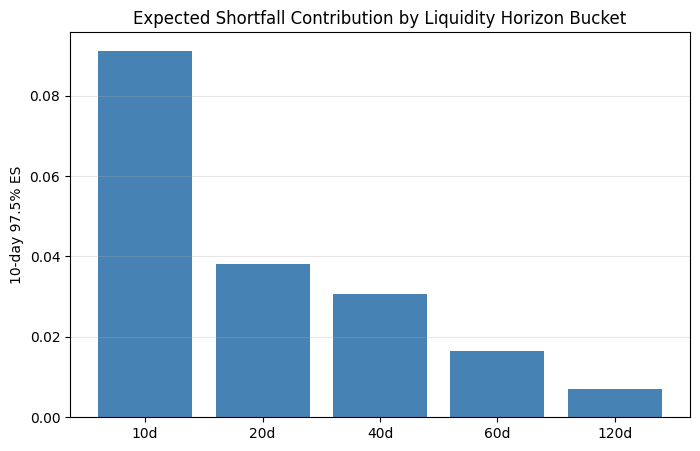

In [28]:
# Visualize the 10-day scaled ES contribution from each liquidity horizon bucket
plt.figure(figsize=(8,5))
plt.bar([str(lh)+'d' for lh in LH_BUCKETS], [es_10day[lh] for lh in LH_BUCKETS], color='steelblue')
plt.ylabel('10-day 97.5% ES')
plt.title('Expected Shortfall Contribution by Liquidity Horizon Bucket')
plt.grid(alpha=0.3, axis='y')
plt.show()

In [29]:
# Build Hypothetical P&L (HPL, full revaluation) and Risk-Theoretical P&L (RTPL, sector-factor sensitivity approximation) for the PLA test
HPL = returns[TICKERS].values @ weights.values
RTPL = (sector_betas.values * weights.values * asset_sector_return.values).sum(axis=1)
HPL = pd.Series(HPL, index=returns.index)
RTPL = pd.Series(RTPL, index=returns.index)
pla_df = pd.DataFrame({'HPL':HPL, 'RTPL':RTPL})
pla_df.tail()

,HPL,RTPL
Date,,
2026-06-30,-0.004272,0.000195
2026-07-01,0.004438,0.000733
2026-07-02,0.011602,0.007059
2026-07-06,0.001774,0.002930
2026-07-07,0.007938,0.002351


In [30]:
# Run the PLA validation test: Spearman correlation and Kolmogorov-Smirnov statistic between HPL and RTPL, using actual Basel PLA thresholds for desk eligibility
window = pla_df.tail(250)
spearman_rho, spearman_p = spearmanr(window['HPL'], window['RTPL'])
ks_stat, ks_p = ks_2samp(window['HPL'], window['RTPL'])

corr_zone = 'Green' if spearman_rho > 0.80 else ('Amber' if spearman_rho >= 0.70 else 'Red')
ks_zone = 'Green' if ks_stat < 0.09 else ('Amber' if ks_stat <= 0.12 else 'Red')
zone_rank = {'Green':0,'Amber':1,'Red':2}
zone = max(corr_zone, ks_zone, key=lambda z: zone_rank[z])

print(f"Spearman correlation: {spearman_rho:.3f} (p={spearman_p:.4f}) -> {corr_zone}")
print(f"KS statistic: {ks_stat:.3f} (p={ks_p:.4f}) -> {ks_zone}")
print(f"Desk eligibility zone: {zone}")

Spearman correlation: 0.900 (p=0.0000) -> Green
KS statistic: 0.060 (p=0.7602) -> Green
Desk eligibility zone: Green


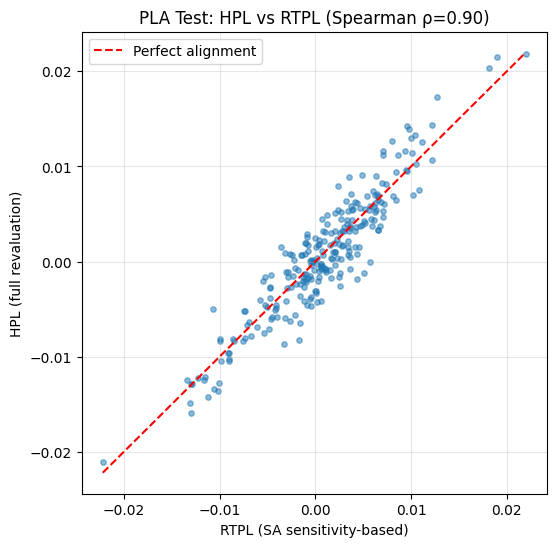

In [31]:
# Visualize the PLA test: HPL vs RTPL scatter plot to inspect alignment between full-revaluation and risk-model P&L
plt.figure(figsize=(6,6))
plt.scatter(window['RTPL'], window['HPL'], alpha=0.5, s=15)
lims = [min(window.min()), max(window.max())]
plt.plot(lims, lims, 'r--', label='Perfect alignment')
plt.xlabel('RTPL (SA sensitivity-based)')
plt.ylabel('HPL (full revaluation)')
plt.title(f'PLA Test: HPL vs RTPL (Spearman ρ={spearman_rho:.2f})')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [32]:
# Automate daily backtesting: compare realized portfolio P&L against the rolling 97.5% ES threshold and count exceptions
roll_window = 250
rolling_es = pd.Series(index=returns.index, dtype=float)
for i in range(roll_window, len(portfolio_pnl_full)):
    hist_window = portfolio_pnl_full[i-roll_window:i]
    rolling_es.iloc[i] = expected_shortfall(hist_window, 0.975)

realized_pnl = pd.Series(portfolio_pnl_full, index=returns.index)
valid = rolling_es.dropna().index
exceptions = realized_pnl.loc[valid] < -rolling_es.loc[valid]
exception_rate = exceptions.mean()
print(f"Number of exceptions: {exceptions.sum()} out of {len(valid)} days")
print(f"Exception rate: {exception_rate*100:.2f}% (target ~2.5%)")

Number of exceptions: 11 out of 1004 days
Exception rate: 1.10% (target ~2.5%)


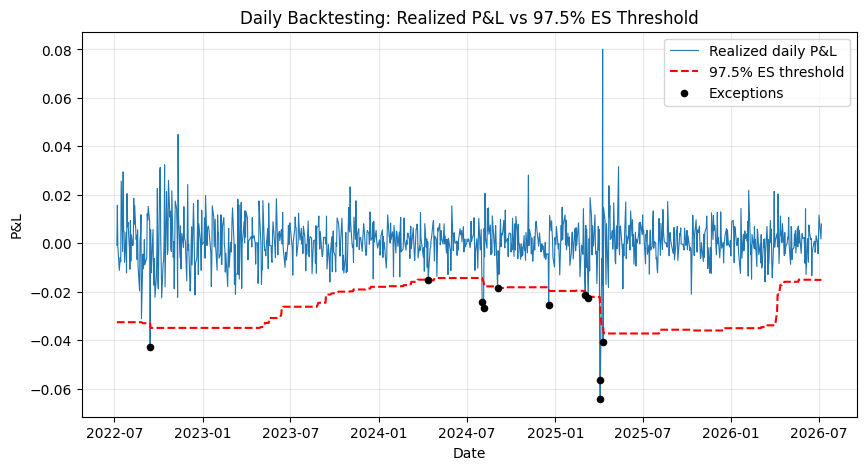

In [33]:
# Visualize the backtest: daily realized P&L against the rolling ES threshold, flagging exceptions
plt.figure(figsize=(10,5))
plt.plot(realized_pnl.loc[valid].index, realized_pnl.loc[valid], label='Realized daily P&L', linewidth=0.8)
plt.plot(valid, -rolling_es.loc[valid], label='97.5% ES threshold', color='red', linestyle='--')
exc_dates = exceptions[exceptions].index
plt.scatter(exc_dates, realized_pnl.loc[exc_dates], color='black', s=20, zorder=5, label='Exceptions')
plt.xlabel('Date'); plt.ylabel('P&L')
plt.title('Daily Backtesting: Realized P&L vs 97.5% ES Threshold')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [34]:
# Compute the Standardized Approach (SA) capital charge as an UNDIVERSIFIED sum of sensitivities (SA gives no diversification credit, by regulatory design), and compare against the IMA (ES-based) capital charge
risk_weight = 0.32
sa_sensitivities = np.abs(sector_betas.values * weights.values) * risk_weight
SA_capital = np.sum(sa_sensitivities) * np.sqrt(10)

exception_count_250 = int((exceptions.tail(250)).sum()) if len(exceptions) >= 250 else int(exceptions.sum())
if exception_count_250 <= 4:
    multiplier = 1.5
elif exception_count_250 <= 9:
    multiplier = 1.5 + 0.1*(exception_count_250-4)
else:
    multiplier = 2.0

IMA_capital = multiplier * ES_regulatory
capital_reduction_pct = (SA_capital - IMA_capital) / SA_capital * 100
print(f"SA capital charge (undiversified): {SA_capital:.4f}")
print(f"Backtest exceptions (last 250d): {exception_count_250} -> multiplier: {multiplier:.2f}")
print(f"IMA capital charge: {IMA_capital:.4f}")
print(f"Capital reduction vs SA baseline: {capital_reduction_pct:.1f}%")

SA capital charge (undiversified): 1.0279
Backtest exceptions (last 250d): 0 -> multiplier: 1.50
IMA capital charge: 0.1675
Capital reduction vs SA baseline: 83.7%


In [35]:
# Print final project summary
print("=== FRTB IMA Risk Engine Summary ===")
print(f"Portfolio: {len(TICKERS)} assets across {len(set(SECTOR_MAP.values()))} sectors")
print(f"Aggregated 97.5% Expected Shortfall (10-day): {ES_regulatory:.4f}")
print(f"PLA Test - Spearman correlation: {spearman_rho:.3f}, KS statistic: {ks_stat:.3f}")
print(f"Desk eligibility: {zone}")
print(f"Backtest exception rate: {exception_rate*100:.2f}% over {len(valid)} days")
print(f"SA capital: {SA_capital:.4f} | IMA capital: {IMA_capital:.4f} | Reduction: {capital_reduction_pct:.1f}%")

=== FRTB IMA Risk Engine Summary ===
Portfolio: 50 assets across 7 sectors
Aggregated 97.5% Expected Shortfall (10-day): 0.1117
PLA Test - Spearman correlation: 0.900, KS statistic: 0.060
Desk eligibility: Green
Backtest exception rate: 1.10% over 1004 days
SA capital: 1.0279 | IMA capital: 0.1675 | Reduction: 83.7%
